# Map Converter
This is a Jupyter Notebook to Convert a `.png` or `.pgm` + `.yaml` of a map into a `.csv` that can be fed into the TUMFTM functions.

High Level Steps:
1. Get the Euclidean Distance Transform of the map
2. Apply skeletonization to the map to extract centerlines
3. Run DFS to extract the centerline xy coordinates in order
4. Apply the transformations to go from pixel to meter coordinate frame


Map Conditions:
- Map edges should be well defined, inside should be white, walls are black and outside is grey

In [5]:
import numpy as np
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt
import yaml
import scipy
from scipy.ndimage import distance_transform_edt as edt
from PIL import Image
import os
from skimage.morphology import (
    opening, closing, remove_small_objects,
    remove_small_holes, skeletonize, disk,
    medial_axis
)
from skimage.filters import gaussian
from skimage.segmentation import flood, flood_fill
from scipy.ndimage import convolve

In [6]:
MAP_NAME = '4_4'

TRACK_WIDTH_MARGIN = 0.0 # Extra Safety margin, in meters

4_4


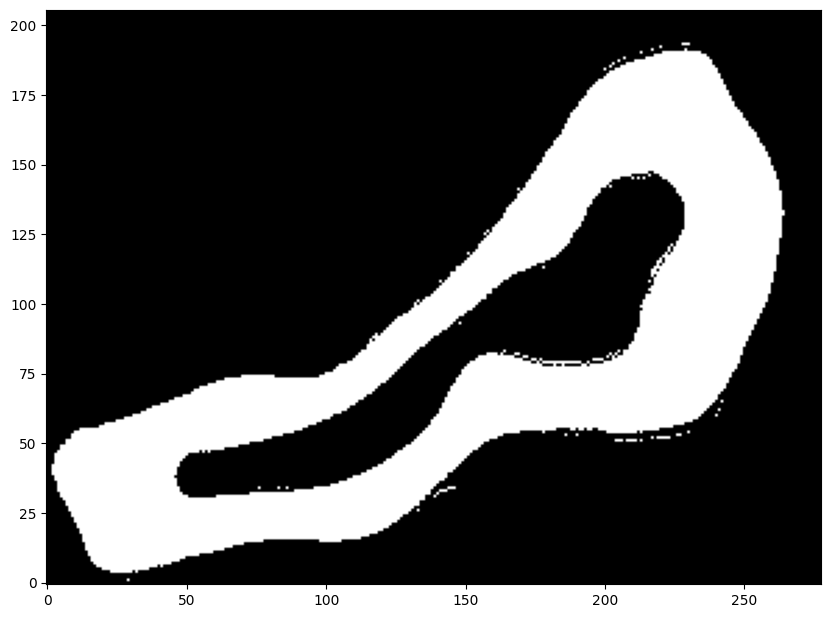

In [7]:
# Load map image

print(MAP_NAME)
if os.path.exists(f"maps/{MAP_NAME}.png"):
    map_img_path = f"maps/{MAP_NAME}.png"
elif os.path.exists(f"maps/{MAP_NAME}.pgm"):
    map_img_path = f"maps/{MAP_NAME}.pgm"
else:
    raise Exception("Map not found!")
if not os.path.exists(f"maps/{MAP_NAME}.yaml"):
    raise Exception("Map yaml not found!")

map_yaml_path = f"maps/{MAP_NAME}.yaml"
raw_map_img = np.array(Image.open(map_img_path).transpose(Image.FLIP_TOP_BOTTOM)) # type: ignore
raw_map_img = raw_map_img.astype(np.float64)

# plt.figure(figsize=(10, 10))
# plt.imshow(raw_map_img, cmap='gray', origin='lower')

# Convert to binary
map_img = raw_map_img.copy()
map_img[map_img <= 210.] = 0
map_img[map_img > 210.] = 1
map_img = map_img.astype(bool)

map_height, map_width = map_img.shape

plt.figure(figsize=(10, 10))
plt.imshow(map_img, cmap='gray', origin='lower')

(206, 278)


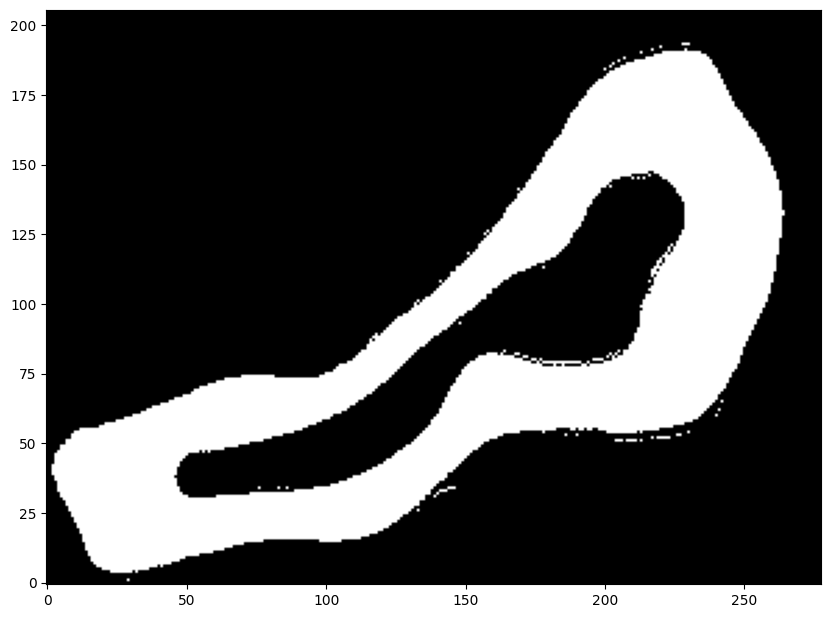

In [ ]:
# Flood Fill

print(map_img.shape)
map_img = flood_fill(map_img, (0, 0), False)
map_img = flood_fill(map_img, (0, map_width-1), False)
map_img = flood_fill(map_img, (map_height-1, 0), False)
map_img = flood_fill(map_img, (map_height-1, map_height-1), False)
# May need to run multiple times
for i in range(0, 1):
    y = map_height // 2
    x = 0
    saw_white = False
    while (not saw_white or map_img[x, y]):
        x += 1
        if map_img[x, y]:
            saw_white = True
    seed = (x, y)
    map_img = flood_fill(map_img, seed, False)

plt.figure(figsize=(10, 10))
plt.imshow(map_img, cmap='gray', origin='lower')

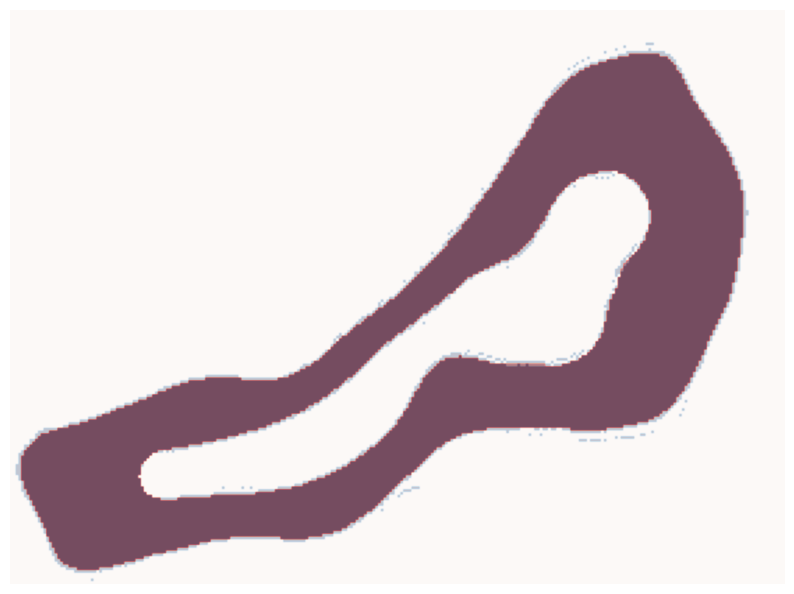

In [9]:
# Cleaning

clean = map_img.copy()
clean = remove_small_objects(clean, min_size=100)    # removes tiny blobs
clean = remove_small_holes(clean, area_threshold=100)      # removes tiny holes
clean = closing(clean, disk(1))   # fills tiny gaps
clean = opening(clean, disk(1))     # removes tiny protrusions

clean = gaussian(clean.astype(float), sigma=3.5) > 0.6 # type: ignore

plt.figure(figsize=(10, 10))
plt.imshow(map_img, origin='lower', cmap='Blues', alpha=0.5)
plt.imshow(clean, origin='lower', cmap='Reds', alpha=0.5)
plt.axis("off")
plt.show()

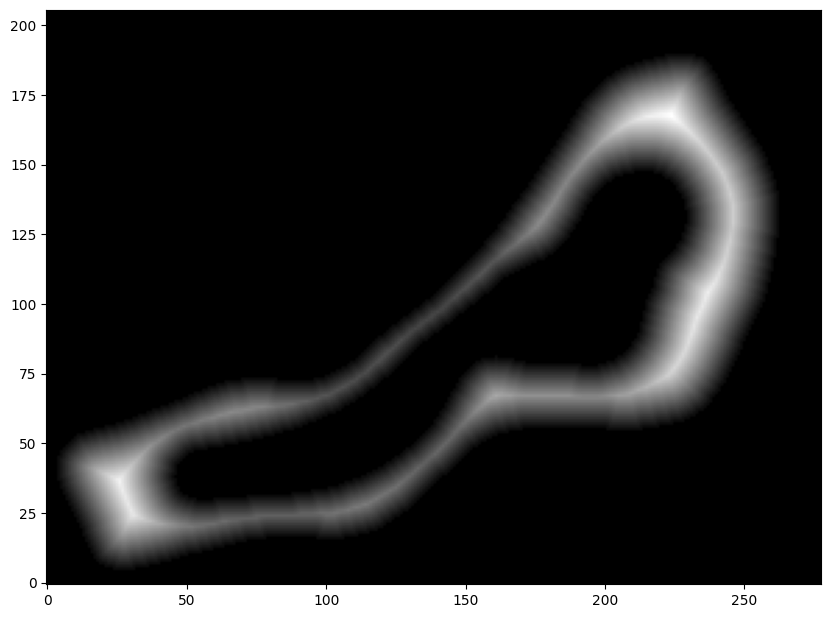

In [ ]:
# Distance Transform

plt.figure(figsize=(10, 10))
# Calculate Euclidean Distance Transform (tells us distance to nearest wall)
dist_transform = scipy.ndimage.distance_transform_edt(clean) # type: ignore
plt.imshow(dist_transform, cmap='gray', origin='lower')

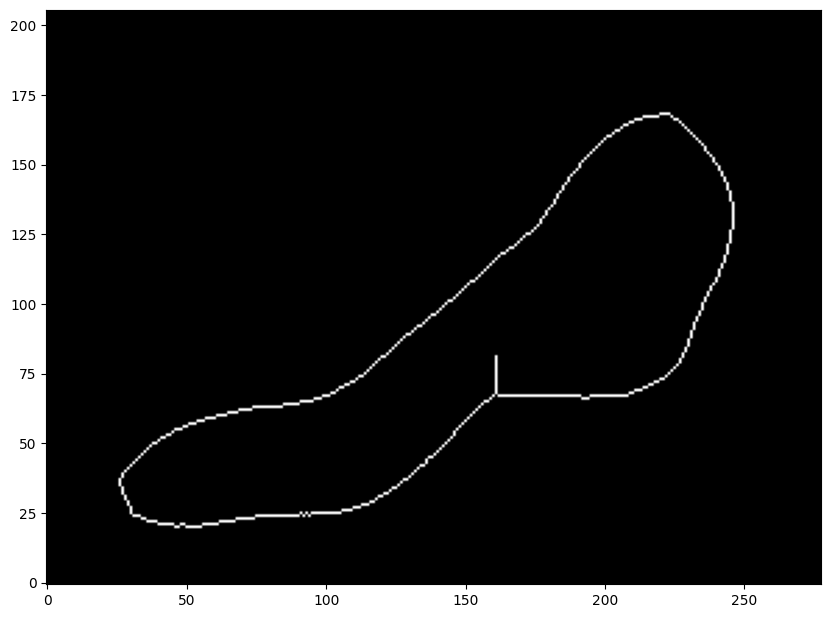

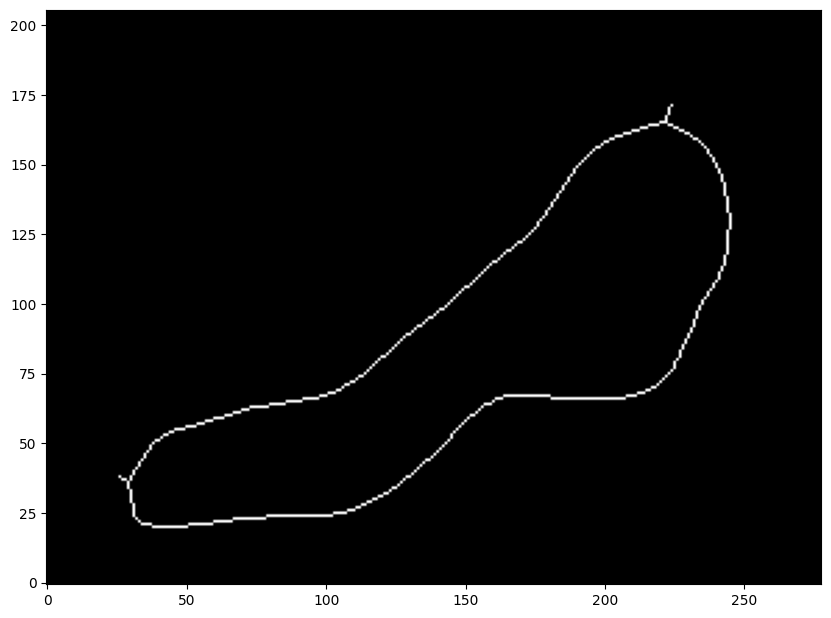

In [ ]:
# Centerline

# centerline, dist_on_centerline = medial_axis(clean, return_distance=True)

# plt.figure(figsize=(10, 10))
# plt.imshow(centerline, origin='lower', cmap='gray')

# Threshold the distance transform to create a binary image

# THRESHOLD = 0.1 # You should play around with this number. Is you say hairy lines generated, either clean the map so it is more curvy or increase this number
# centers = (dist_transform > THRESHOLD*dist_transform.max()).astype(np.uint8)
# plt.figure(figsize=(10, 10))
# plt.imshow(centers, origin='lower', cmap='gray')

centerline = skeletonize(clean)

plt.figure(figsize=(10, 10))
plt.imshow(centerline, origin='lower', cmap='gray')

RuntimeError: Unexpected second neighbor counts [2 2]

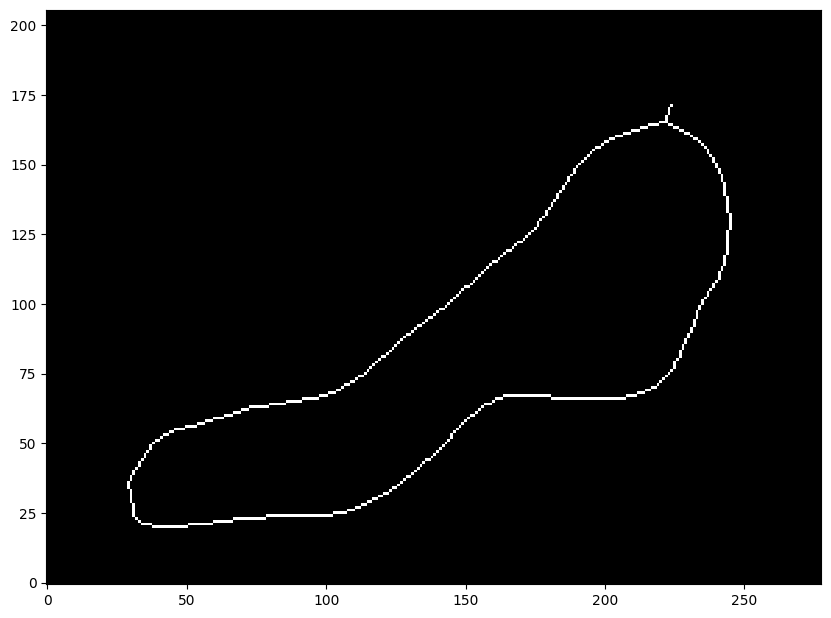

In [ ]:
# Pruning

neighbors = convolve(centerline.astype(np.int8), 
                     np.ones((3, 3), dtype=np.int8), 
                     mode='constant', 
                     cval=0).astype(np.int8)
neighbors = neighbors - centerline.astype(np.int8)
neighbors[~centerline] = 0
endpoints = np.argwhere(neighbors == 1)

def get_neighbors(row, col, centerline):
   # Handle map edges
   c1 = max(0, col - 1)
   c2 = min(map_width, col + 2)
   r1 = max(0, row - 1)
   r2 = min(map_height, row + 2)
   local = np.argwhere(centerline[r1:r2, c1:c2])
   idxs = local + [r1, c1]
   idxs = idxs[~np.all(idxs == [row, col], axis=1)]
   return idxs

for cur in endpoints:
    while True:
        imm_neighbors = get_neighbors(*cur, centerline) #type: ignore
        n = len(imm_neighbors)
        if n == 2:
            second_neigh_counts = np.array([len(get_neighbors(*neigh, centerline)) for neigh in imm_neighbors])
            if np.all(second_neigh_counts == 3):
                centerline[tuple(cur)] = False
            elif np.any(second_neigh_counts == 3):
                raise RuntimeError(f'Unexpected second neighbor counts {second_neigh_counts}')
            break
        centerline[tuple(cur)] = False
        if n == 0:
            break
        cur = imm_neighbors[0]

plt.figure(figsize=(10, 10))
plt.imshow(centerline, origin='lower', cmap='gray', interpolation='none')

In [13]:
# The centerline has the track width encoded
centerline_dist = np.where(centerline, dist_transform, 0)
NON_EDGE = 0.0
# Use DFS to extract the outer edge
left_start_y = map_height // 2
left_start_x = 0
while (centerline_dist[left_start_y][left_start_x] == NON_EDGE): 
	left_start_x += 1

print(f"Starting position for left edge: {left_start_x} {left_start_y}")

Starting position for left edge: 147 103


In [14]:
# Run DFS

import sys
sys.setrecursionlimit(20000)

visited = {}
centerline_points = []
track_widths = []
# DIRECTIONS = [(0, 1), (1, 0), (0, -1), (-1, 0), (1, 1), (1, -1), (-1, 1), (-1, -1)]
# If you want the other direction first
DIRECTIONS = [(0, -1), (-1, 0),  (0, 1), (1, 0), (-1, 1), (-1, -1), (1, 1), (1, -1) ]

starting_point = (left_start_x, left_start_y)

def dfs(point):
	if (point in visited): return
	visited[point] = True
	centerline_points.append(np.array(point))
	track_widths.append(np.array([centerline_dist[point[1]][point[0]], centerline_dist[point[1]][point[0]]]))

	for direction in DIRECTIONS:
		if (centerline_dist[point[1] + direction[1]][point[0] + direction[0]] != NON_EDGE and (point[0] + direction[0], point[1] + direction[1]) not in visited):
			dfs((point[0] + direction[0], point[1] + direction[1]))

dfs(starting_point)

# Conversion
Convert into Pandas, and go from pixels to meters, and then shift by the origin.

In [15]:
track_widths_np = np.array(track_widths)
waypoints = np.array(centerline_points)
print(f"Track widths shape: {track_widths_np.shape}, waypoints shape: {waypoints.shape}")

Track widths shape: (505, 2), waypoints shape: (505, 2)


In [16]:
# Merge track with waypoints
data = np.concatenate((waypoints, track_widths_np), axis=1)
data.shape

(505, 4)

In [17]:
# load map yaml
with open(map_yaml_path, 'r') as yaml_stream:
    try:
        map_metadata = yaml.safe_load(yaml_stream)
        map_resolution = map_metadata['resolution']
        origin = map_metadata['origin']
    except yaml.YAMLError as ex:
        print(ex)

# calculate map parameters
orig_x = origin[0]
orig_y = origin[1]

# get the distance transform
transformed_data = data
transformed_data *= map_resolution
transformed_data += np.array([orig_x, orig_y, 0, 0])

# Safety margin
transformed_data -= np.array([0, 0, TRACK_WIDTH_MARGIN, TRACK_WIDTH_MARGIN])

In [18]:
# Uncomment this if you get the following error: raise IOError("At least two spline normals are crossed, check input or increase smoothing factor!")
# transformed_data = transformed_data[::4]

In [19]:
with open(f"inputs/tracks/{MAP_NAME}.csv", 'wb') as fh:
    np.savetxt(fh, transformed_data, fmt='%0.4f', delimiter=',', header='x_m,y_m,w_tr_right_m,w_tr_left_m')

Next up, check out `sanity_check.ipynb` to make sure that the centerline generated lines up with the map.